In [3]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from strategy.signals import generate_intraday_signals
from backtest.engine import run_backtest
from analytics.performance import compute_performance

In [5]:
file_path = "../data/GCcv1.csv"

df = pd.read_csv(file_path)

# Datetime
df['Date-Time'] = pd.to_datetime(df['Date-Time'])
df.set_index('Date-Time', inplace=True)
df.index = df.index.tz_convert(None)

# Rename
df.rename(columns={
    'Open': 'open',
    'High': 'high',
    'Low': 'low',
    'Last': 'close',
    'Volume': 'volume'
}, inplace=True)

# Drop junk
if '#RIC' in df.columns:
    df.drop(columns=['#RIC'], inplace=True)

# Clean
df = df.sort_index()

for col in ['open', 'high', 'low', 'close']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(inplace=True)

print(df.head())
print("Rows:", len(df))

                       open    high     low   close  volume
Date-Time                                                  
2024-04-03 00:00:00  2300.1  2301.2  2299.5  2301.2     168
2024-04-03 00:01:00  2301.2  2301.8  2301.2  2301.5     149
2024-04-03 00:02:00  2301.4  2302.1  2301.2  2302.0     167
2024-04-03 00:03:00  2302.0  2302.7  2301.7  2301.7     119
2024-04-03 00:04:00  2301.8  2302.3  2301.1  2301.1      50
Rows: 702644


In [6]:
df = generate_intraday_signals(df)

print("Total Signals:", int(df['signal'].sum()))

df[['close', 'signal']].tail()

Total Signals: 63


,close,signal
Date-Time,,
2026-04-10 19:56:00,4783.8,0.0
2026-04-10 19:57:00,4784.2,0.0
2026-04-10 19:58:00,4783.8,0.0
2026-04-10 19:59:00,4783.6,0.0
2026-04-10 20:00:00,4782.5,0.0


In [7]:
df, trades_df, results = run_backtest(
    df,
    initial_capital=1.0,
    risk_pct=0.02,
    slippage=0.0005
)

results

{'final_equity': 0.0, 'max_drawdown': -1.0, 'total_trades': 50}

In [8]:
perf = compute_performance(df, trades_df)

for k, v in perf.items():
    print(f"{k:<25}: {v:.4f}" if isinstance(v, float) else f"{k:<25}: {v}")

final_equity             : 0.0000
cagr                     : -1.0000
sharpe                   : nan
max_drawdown             : -1.0000
total_trades             : 50
win_rate                 : 0.1400
avg_win                  : 0.0592
avg_loss                 : -0.0165
expectancy               : -0.0059
avg_holding              : 15.2800


d:\quant-research-portfolio\.venv\Lib\site-packages\pandas\core\nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


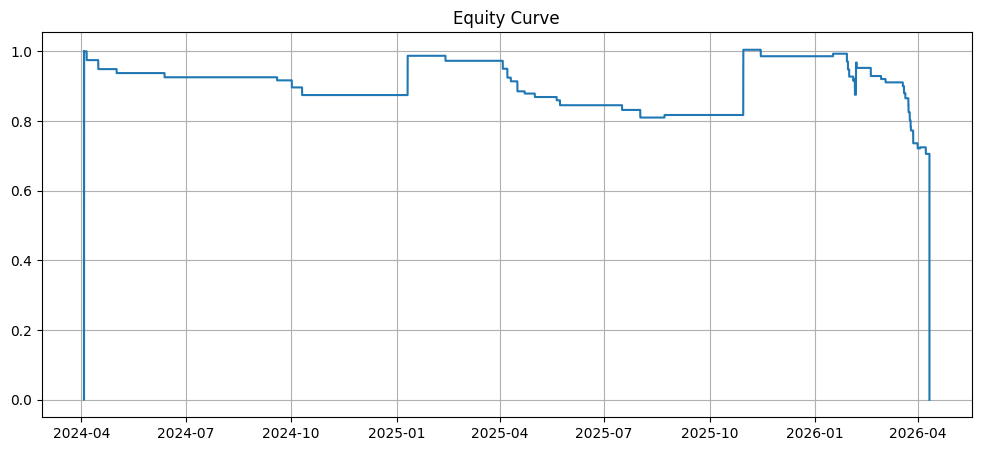

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['equity_curve'])
plt.title("Equity Curve")
plt.grid()
plt.show()

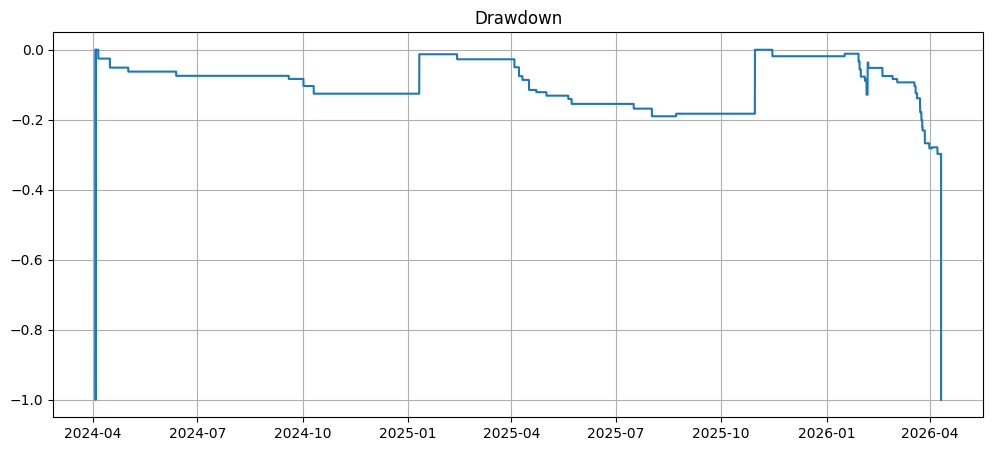

In [10]:
equity = df['equity_curve']
peak = equity.cummax()
drawdown = (equity - peak) / peak

plt.figure(figsize=(12, 5))
plt.plot(df.index, drawdown)
plt.title("Drawdown")
plt.grid()
plt.show()

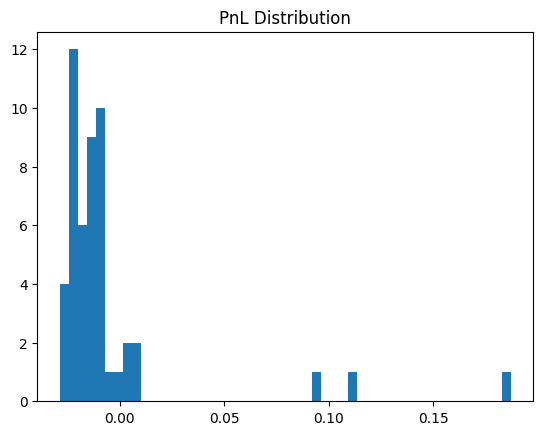

In [11]:
plt.hist(trades_df['pnl'], bins=50)
plt.title("PnL Distribution")
plt.show()

In [12]:
wins = trades_df[trades_df['pnl'] > 0]
losses = trades_df[trades_df['pnl'] < 0]

print("Wins:", len(wins))
print("Losses:", len(losses))

Wins: 7
Losses: 43


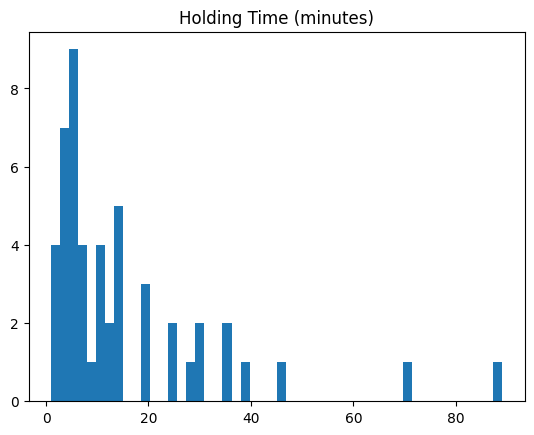

In [13]:
if 'holding_minutes' in trades_df.columns:
    plt.hist(trades_df['holding_minutes'], bins=50)
    plt.title("Holding Time (minutes)")
    plt.show()